# Clustering to discover latent emotions

Starting from HR_data_PC2, I try to identify different clusters with gmm


--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---
Emotional_Cluster         0         1         2
Frustrated         2.229358  2.255319  1.807692
upset              1.385321  1.531915  1.262821
hostile            1.036697  1.170213  1.038462
alert              2.348624  2.000000  2.141026
ashamed            1.256881  1.319149  1.166667
inspired           2.495413  1.787234  2.085691
nervous            1.385321  1.425532  1.365385
attentive          3.000000  2.531915  2.710157
afraid             1.064220  1.042553  1.045202
active             2.798165  2.234043  2.477904
determined         3.210210  2.553191  2.813544


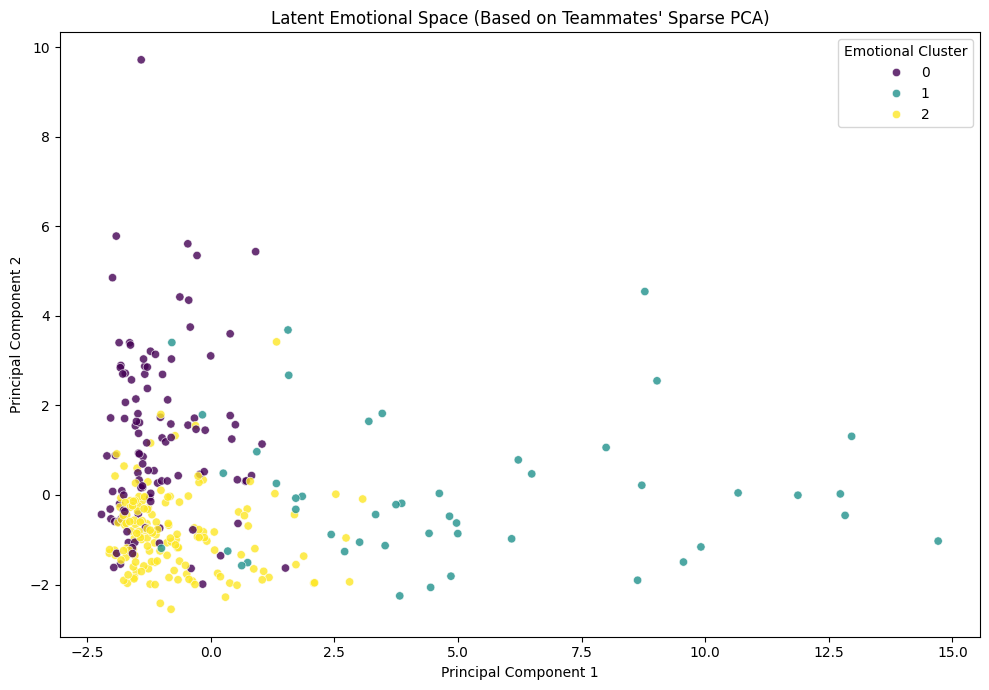


--- Methodological Verification: Phase Distribution ---
Emotional_Cluster   0   1   2
Phase                        
phase1             33  11  60
phase2             41  18  45
phase3             35  18  51


In [2]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os
from pathlib import Path

base_path = Path(os.getcwd()).resolve().parents[0] 

pca_data_path = base_path / 'data' / 'processed' / 'HR_data_PCA2.csv'
raw_data_path = base_path / 'data' / 'processed' / 'HR_data_2.csv'


df_pca = pd.read_csv(pca_data_path)
df_raw = pd.read_csv(raw_data_path)

# 1. Identify the Principal Components
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]

# 2. GMM CLUSTERING
# We look for 3 latent emotional profiles (K=3)
gmm = GaussianMixture(n_components=3, random_state=42)
df_pca['Emotional_Cluster'] = gmm.fit_predict(df_pca[pc_cols])

# 3. PSYCHOLOGICAL INTERPRETATION
# Map the clusters back to the raw dataset to analyze questionnaire scores
df_raw['Emotional_Cluster'] = df_pca['Emotional_Cluster']

questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

# Calculate the mean score for each emotion within each cluster
emotional_profile = df_raw.groupby('Emotional_Cluster')[questionnaire_cols].mean()

print("\n--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---")
print(emotional_profile.T) 

# 4. VISUALIZATION
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca['PC1'], 
    y=df_pca['PC2'], 
    hue=df_pca['Emotional_Cluster'], 
    palette='viridis', 
    alpha=0.8
)
plt.title('Latent Emotional Space (Based on Teammates\' Sparse PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Emotional Cluster')
plt.tight_layout()
plt.show()

# 5. METHODOLOGICAL VERIFICATION
# Check if clusters are still tied to experimental phases (they shouldn't be)
print("\n--- Methodological Verification: Phase Distribution ---")
print(pd.crosstab(df_pca['Phase'], df_pca['Emotional_Cluster']))

We can imagine it to be
* 0: determined and engaged
* 1: frustrated
* 2: neutral